<a href="https://colab.research.google.com/github/Shelly2000/vehicle-demand-forecasting/blob/main/vehicle_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files
uploaaded= files.upload()
import io

Saving train_E1GspfA.csv to train_E1GspfA (2).csv


In [ ]:
#carregar dados


df = pd.read_csv('train_E1GspfA.csv')
df.head()

,date,hour,demand
0,2018-08-18,9,91
1,2018-08-18,10,21
2,2018-08-18,13,23
3,2018-08-18,14,104
4,2018-08-18,15,81


In [ ]:
print("Dimensão do dataset:", df.shape)
print("\nTipos de dados do dataset:")
print(df.dtypes)
print("\nEstatisticas descritivas do dataset:")
print(df.describe())

Dimensão do dataset: (18247, 3)

Tipos de dados do dataset:
date      object
hour       int64
demand     int64
dtype: object

Estatisticas descritivas do dataset:
               hour        demand
count  18247.000000  18247.000000
mean      12.614731     73.991451
std        6.544963     41.678988
min        0.000000      1.000000
25%        8.000000     43.000000
50%       13.000000     71.000000
75%       18.000000     98.000000
max       23.000000    379.000000


In [ ]:
#converter data
df['date']= pd.to_datetime(df['date'])

#procura total
daily_demand= df.groupby(df['date'].dt.date)['demand'].sum()

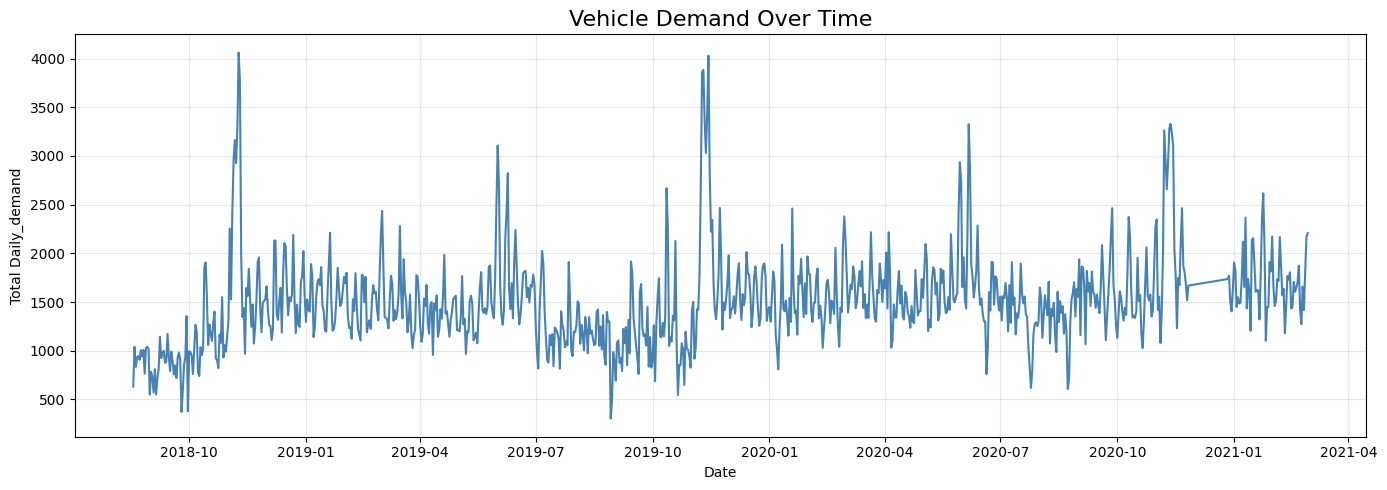

In [ ]:
#Grafico

plt.figure(figsize=(14,5))
plt.plot(daily_demand.index, daily_demand.values, color='steelblue', linewidth=1.5)
plt.title('Vehicle Demand Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Daily_demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

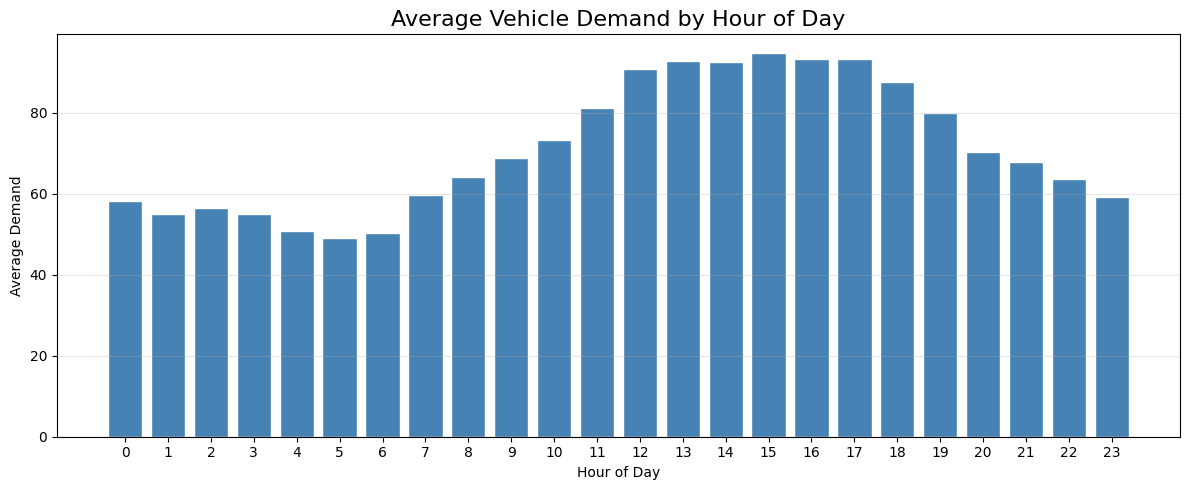

In [ ]:
# Procura média por hora do dia
hourly_demand = df.groupby('hour')['demand'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly_demand.index, hourly_demand.values, color='steelblue', edgecolor='white')
plt.title('Average Vehicle Demand by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

# Preparar dados
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Features e target
X = df[['hour', 'day_of_week', 'month']]
y = df['demand']

# Modelo
model = LinearRegression()
model.fit(X, y)

# Previsão
y_pred = model.predict(X)

# Erro médio
mae = mean_absolute_error(y, y_pred)
print(f"Erro médio absoluto: {mae:.2f} carros")
print(f"Procura média real: {y.mean():.2f} carros")

Erro médio absoluto: 31.44 carros
Procura média real: 73.99 carros


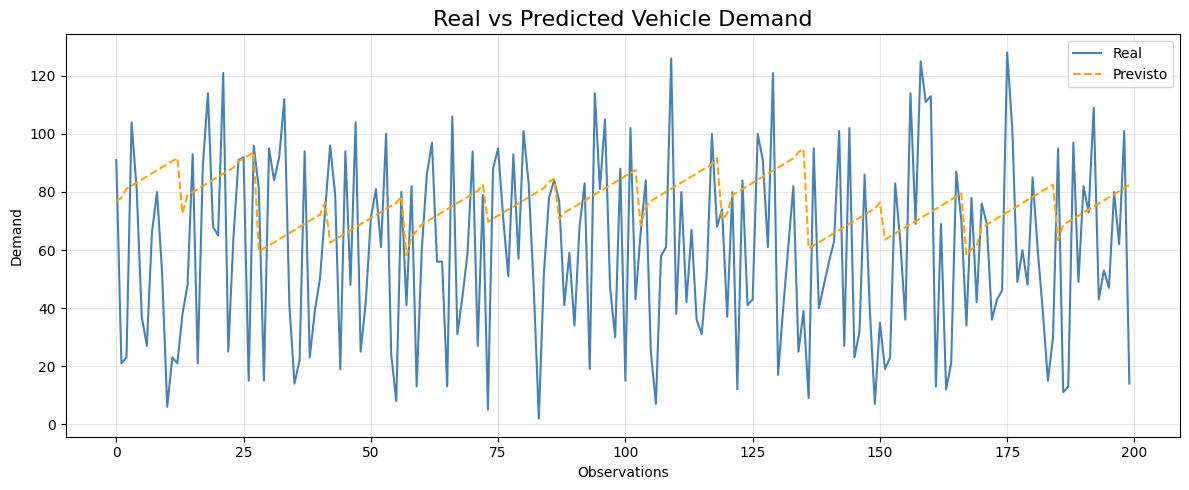

In [ ]:
# Gráfico real vs previsto
plt.figure(figsize=(12, 5))
plt.plot(y.values[:200], label='Real', color='steelblue', linewidth=1.5)
plt.plot(y_pred[:200], label='Previsto', color='orange', linewidth=1.5, linestyle='--')
plt.title('Real vs Predicted Vehicle Demand', fontsize=16)
plt.xlabel('Observations')
plt.ylabel('Demand')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Vehicle Demand Forecasting

## Overview
Exploratory data analysis and demand forecasting applied to vehicle rental time series data using Python.

## Tools
- Python, pandas, matplotlib, seaborn, scikit-learn

## Key Findings
- Peak demand occurs between 12h-17h
- Linear regression model achieved MAE of 31 cars (mean demand: 74)
- Clear seasonality patterns identified in 2018-2021 data

## Author
Sheldra Lopes | Planning & Pricing Analyst at SIXT Portugal

